In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [164]:
df = pd.read_csv('46400_AS05_Loads_stats_Spring2026.csv', sep=';', skiprows=[1],
                  parse_dates=['rname'], date_parser=lambda x: pd.to_datetime(x, format='%Y%m%d%H%M', errors='coerce'))
df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_8104\2035159915.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv('46400_AS05_Loads_stats_Spring2026.csv', sep=';', skiprows=[1],


,rname,Wsp_44m,Wsp_44m_stdev,Wdir_41m,ROT,yaw,pa,po,wsn,MyTB_mean,...,MyA1_DEL9,MyA1_DEL12,MxA1_mean,MxA1_stdev,MxA1_min,MxA1_max,MxA1_DEL3,MxA1_DEL6,MxA1_DEL9,MxA1_DEL12
0,2017-01-01 20:40:00,6.36,0.66,282.66,20.55,278.61,-1.77,175.50,6.81,-887.597,...,269.619,276.271,-211.509,47.3831,-360.007,37.0285,74.6592,142.7520,195.733,231.585
1,2017-01-01 20:50:00,6.68,0.47,283.25,20.30,278.61,-1.79,169.60,6.71,-855.687,...,266.767,272.674,-205.411,32.0547,-331.265,-118.0460,53.1841,86.3817,111.966,129.650
2,2017-01-01 21:00:00,6.24,0.46,278.10,18.60,278.61,-1.67,133.07,6.11,-690.603,...,266.548,273.040,-165.332,30.6360,-274.459,-79.2139,49.5711,80.4282,103.191,118.637
3,2017-01-01 21:20:00,6.07,0.50,280.70,18.88,278.61,-1.73,133.55,6.22,-708.469,...,267.087,273.637,-169.816,38.8028,-303.106,-82.3943,49.3179,84.2135,112.190,130.894
4,2017-01-01 21:30:00,5.90,0.47,283.28,19.25,278.61,-1.74,121.60,6.41,-684.019,...,266.315,272.631,-167.399,30.2279,-295.519,-84.0601,50.8816,84.6000,110.266,127.860


Mask as pd.Series initialized in order to account for all the filters.

In [154]:
mask = pd.Series(True, index=df.index)

report = []  # to store results of filtering steps

Plotting to check unusual data points

In [155]:
def plot_wsp_with_stdev(df):
    plt.figure(figsize=(12, 4))
    
    plt.plot(df['rname'], df["Wsp_44m"], label="Wsp_44m (mean)")
    plt.plot(df['rname'], df["Wsp_44m_stdev"], label="Wsp_44m_stdev")
    
    plt.title("Wind Speed at 44m (Mean & Std Dev)")
    plt.xlabel("Time")
    plt.ylabel("Wind Speed (m/s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

From a first visualization, it is easy to spot some flawed values (Wsp ~ 1e7) so a filter for a maximum velocity of 30 m/s is applied.

Removed 46 rows where Wsp_44m > 30 m/s


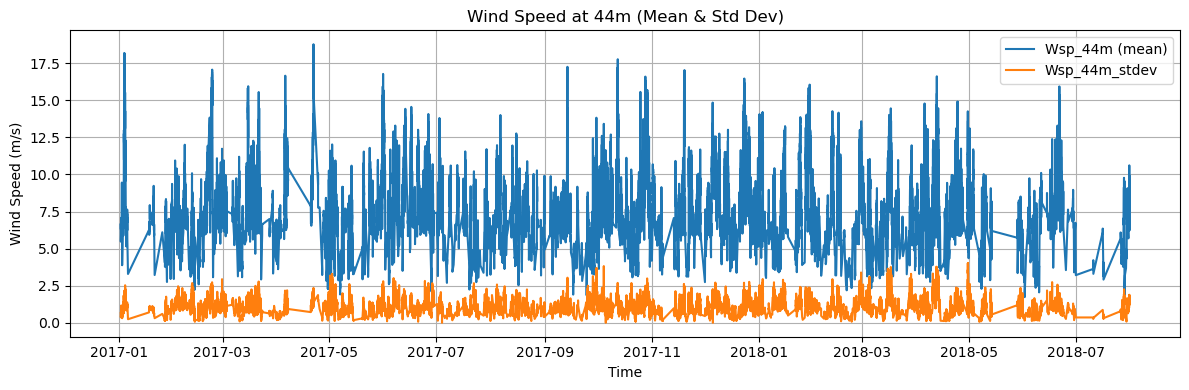

In [156]:
before = mask.sum()

wsp_mask = (df["Wsp_44m"] < 30)
mask &= wsp_mask
after = mask.sum()

print(f"Removed {len(df) - len(df[mask])} rows where Wsp_44m > 30 m/s")

removed = before - after
report.append(("wsp < 30 m/s", removed, after))

plot_wsp_with_stdev(df[mask])

In [157]:
meteo_cols = ["Wdir_41m"]  # wind direction

operational_cols = [
    "ROT",   # rotor velocity
    "yaw",
    "pa",    # pitch angle
    "po",    # active power
    "wsn"
]

def plot_columns(df, columns, title_prefix):
    for col in columns:
        if col not in df.columns:
            print(f"Skipping {col} (not found)")
            continue
        
        plt.figure(figsize=(12, 4))
        plt.plot(df['rname'], df[col])
        plt.title(f"{title_prefix}: {col}")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

Meteorological and operational parameters plots.

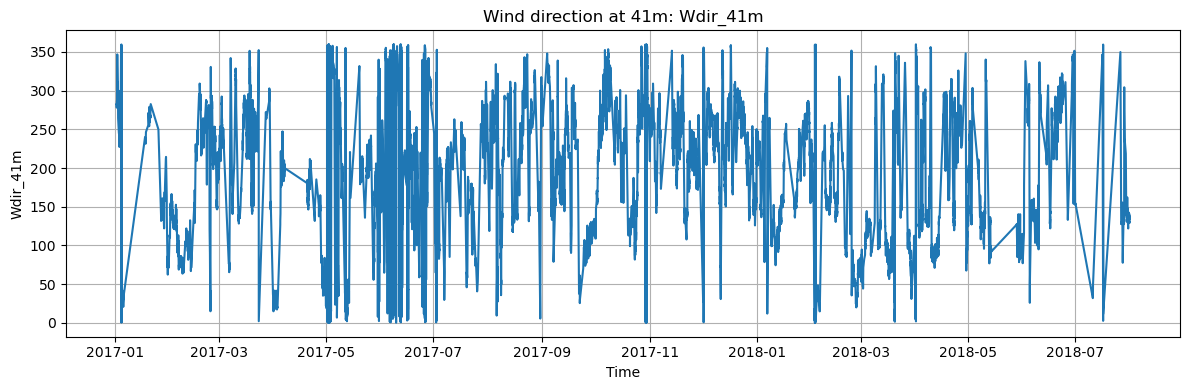

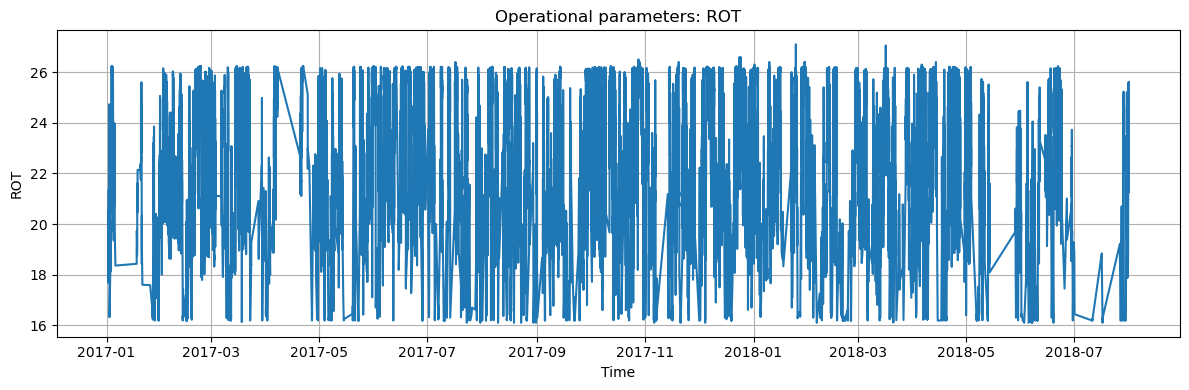

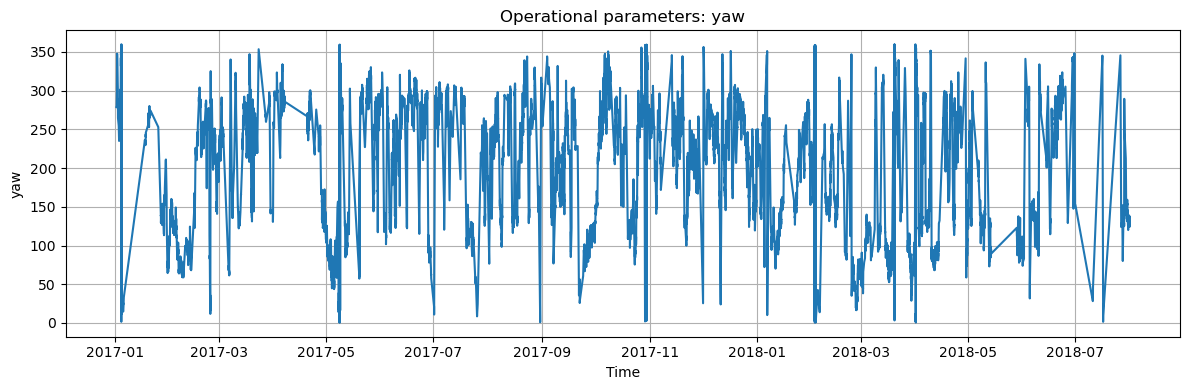

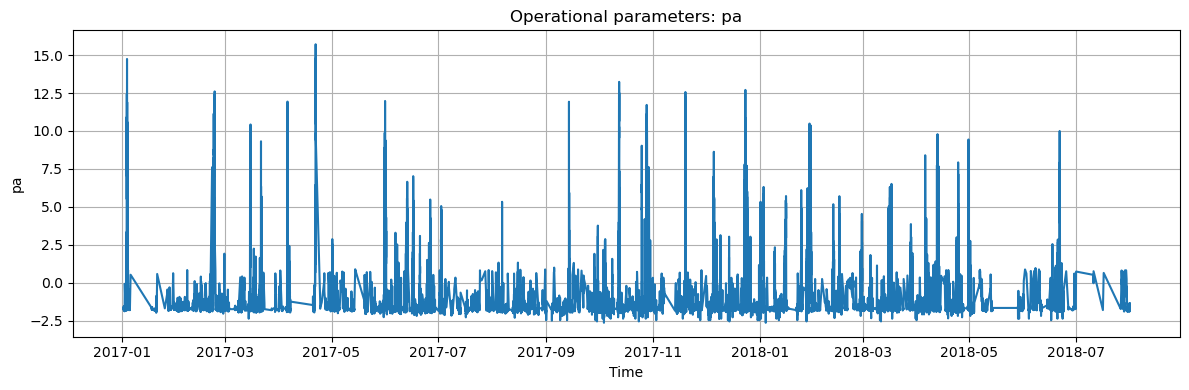

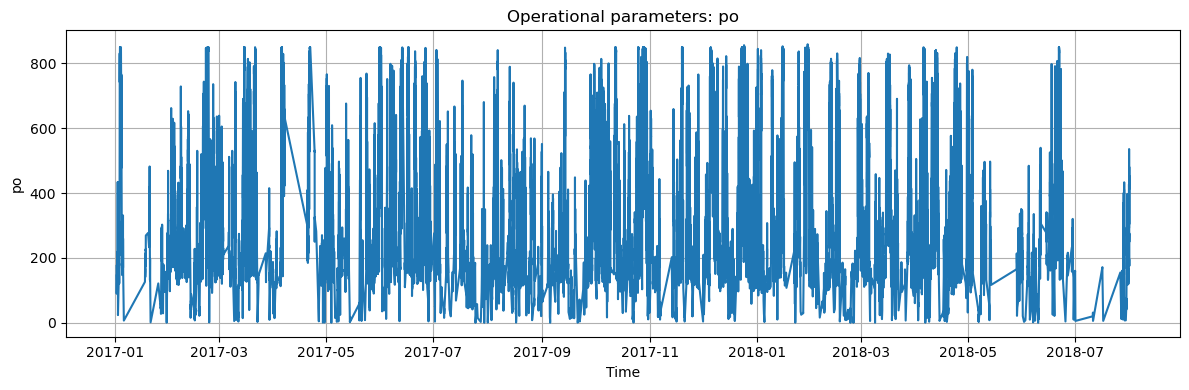

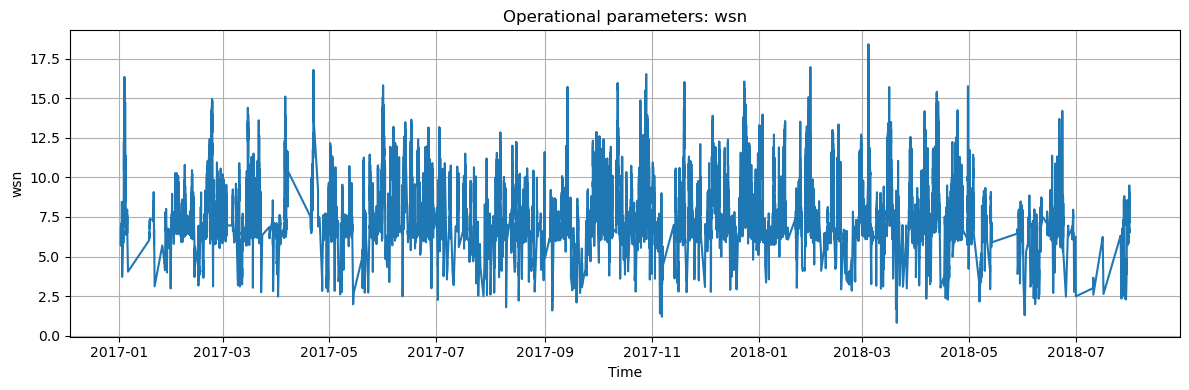

In [158]:
plot_columns(df, meteo_cols, "Wind direction at 41m")

plot_columns(df, operational_cols, "Operational parameters")

Ensuring rotor speed limits are respected.

In [159]:
before = mask.sum()

rotor_limits = ((df['ROT'] > 16) & (df['ROT'] < 26.5))
mask &= rotor_limits

after = mask.sum()
removed = before - after

report.append(("ROT speed limits (16-26.5 rpm)", removed, after))
print(f"Removed {removed} rows based on ROT limits")

Removed 7 rows based on ROT limits


Wind vane measurements between 2017-03-30 11:10 & 2017-08-08 13:50 are found to be invalid. Therefore, all the values collected in that period must be filtered out because many other measurements are direction-dependant (such as wake-free sectors and energy production in wake-free sectors, load analysis vs inflow angle) and yaw directions cannot be verified (*even because they are strictly correlated most of the times due to yaw angles being considered the "absolute" wind direction in e.g. SCADA*) although not implying wind turbine production was faulted.

In [160]:
before = mask.sum()

start = pd.Timestamp('2017-03-30 11:10')
end = pd.Timestamp('2017-08-08 13:50')

time_mask = (df['rname'] < start) | (df['rname'] > end)
mask &= time_mask

after = mask.sum()
removed = before - after

report.append(("Valid time period", removed, after))
print(f"Removed {removed} rows based on valid time period")


Removed 5052 rows based on valid time period


Valid sector is within 260 and 320 deg (320 excluded).

In [161]:
before = mask.sum()

sector_mask = (df['Wdir_41m'] >= 260) & (df['Wdir_41m'] < 320)
mask &= sector_mask

after = mask.sum()
removed = before - after

report.append(("Wind direction sector (260-320 degrees)", removed, after))
print(f"Removed {removed} rows based on wind direction sector (260-320 degrees)")

Removed 14114 rows based on wind direction sector (260-320 degrees)


In [162]:
report_df = pd.DataFrame(report, columns=["Filter", "Removed", "Remaining"])

print(report_df)

                                    Filter  Removed  Remaining
0                             wsp < 30 m/s       46      24483
1           ROT speed limits (16-26.5 rpm)        7      24476
2                        Valid time period     5052      19424
3  Wind direction sector (260-320 degrees)    14114       5310


Dropping the 'False' values to np.nan to avoid further miscalculation. 

In [171]:
final_df = df[mask].copy()
final_df.loc[~mask] = np.nan  # set removed rows to NaN for clarity
final_df # sanity check with report outcome

,rname,Wsp_44m,Wsp_44m_stdev,Wdir_41m,ROT,yaw,pa,po,wsn,MyTB_mean,...,MyA1_DEL9,MyA1_DEL12,MxA1_mean,MxA1_stdev,MxA1_min,MxA1_max,MxA1_DEL3,MxA1_DEL6,MxA1_DEL9,MxA1_DEL12
0,2017-01-01 20:40:00,6.36,0.66,282.66,20.55,278.61,-1.77,175.50,6.81,-887.597,...,269.619,276.271,-211.5090,47.3831,-360.00700,37.0285,74.6592,142.7520,195.7330,231.5850
1,2017-01-01 20:50:00,6.68,0.47,283.25,20.30,278.61,-1.79,169.60,6.71,-855.687,...,266.767,272.674,-205.4110,32.0547,-331.26500,-118.0460,53.1841,86.3817,111.9660,129.6500
2,2017-01-01 21:00:00,6.24,0.46,278.10,18.60,278.61,-1.67,133.07,6.11,-690.603,...,266.548,273.040,-165.3320,30.6360,-274.45900,-79.2139,49.5711,80.4282,103.1910,118.6370
3,2017-01-01 21:20:00,6.07,0.50,280.70,18.88,278.61,-1.73,133.55,6.22,-708.469,...,267.087,273.637,-169.8160,38.8028,-303.10600,-82.3943,49.3179,84.2135,112.1900,130.8940
4,2017-01-01 21:30:00,5.90,0.47,283.28,19.25,278.61,-1.74,121.60,6.41,-684.019,...,266.315,272.631,-167.3990,30.2279,-295.51900,-84.0601,50.8816,84.6000,110.2660,127.8600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24341,2018-06-29 02:30:00,6.96,0.59,297.81,19.46,297.41,-1.77,174.50,6.44,-445.093,...,257.020,265.557,-166.1990,38.5544,-288.80200,-82.2609,40.7678,78.0579,105.7260,123.9100
24342,2018-06-29 02:50:00,6.84,0.58,307.61,18.54,306.62,-1.72,157.74,6.08,-206.250,...,258.204,267.155,-146.8000,30.8553,-242.34300,-62.7121,40.4131,66.2236,87.9940,103.3540
24442,2018-07-28 21:00:00,1.68,0.40,304.34,16.20,272.63,0.14,13.70,3.70,163.032,...,229.071,242.102,55.4512,13.9358,-4.43002,114.6720,17.7782,37.8901,54.4215,66.0145
24443,2018-07-28 21:10:00,1.42,0.39,274.56,16.20,289.48,0.14,13.70,3.70,127.257,...,225.218,238.549,58.7726,7.7086,35.91250,80.7175,10.1262,16.0012,20.9358,24.9505


Timeseries plotting applying filters.

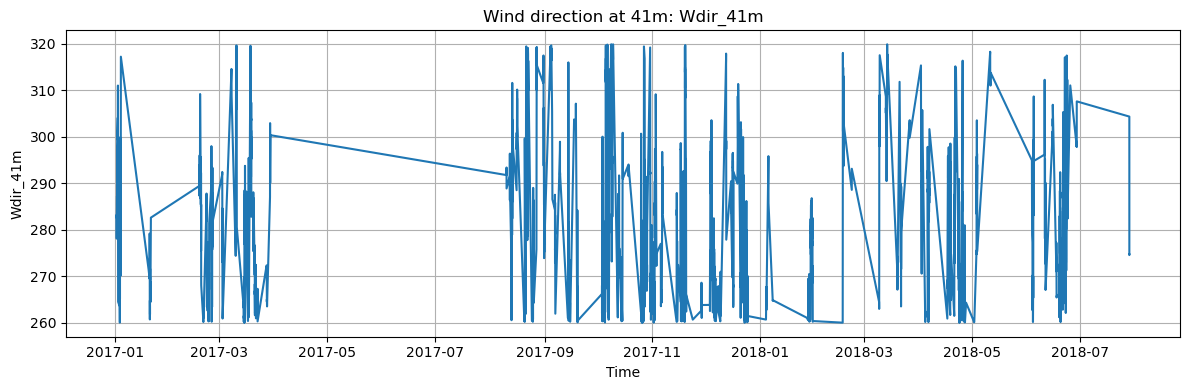

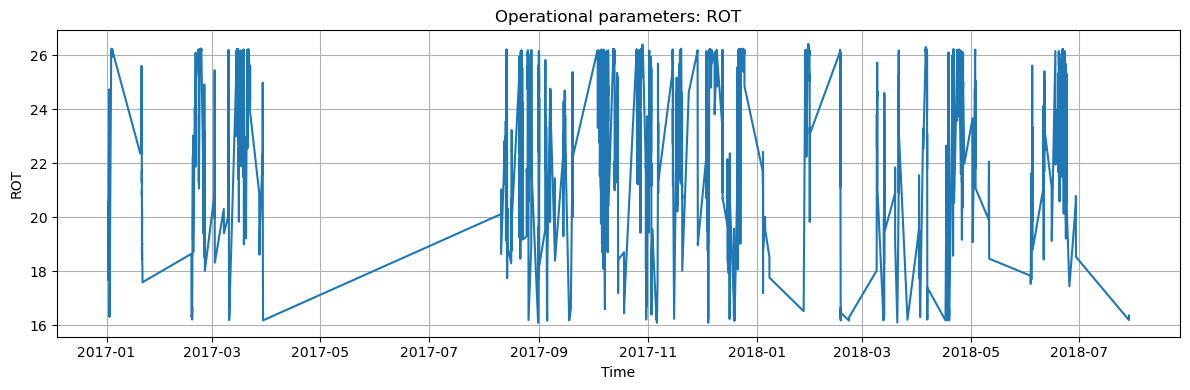

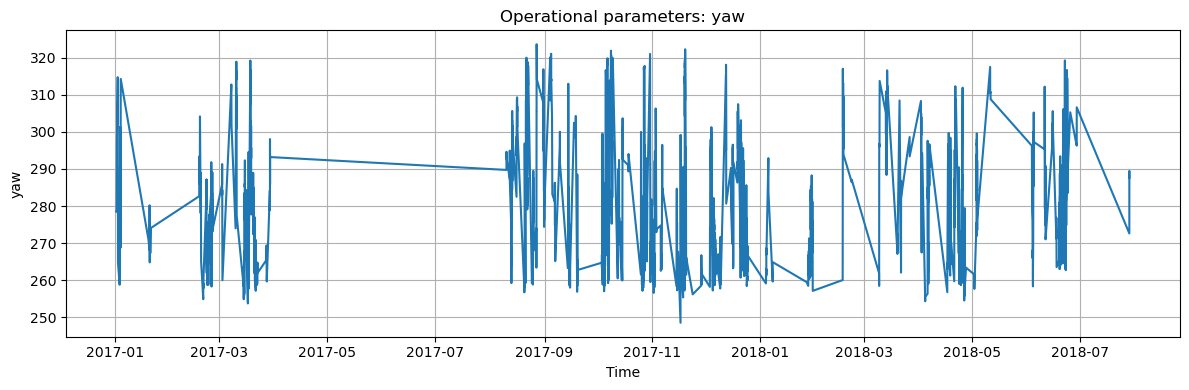

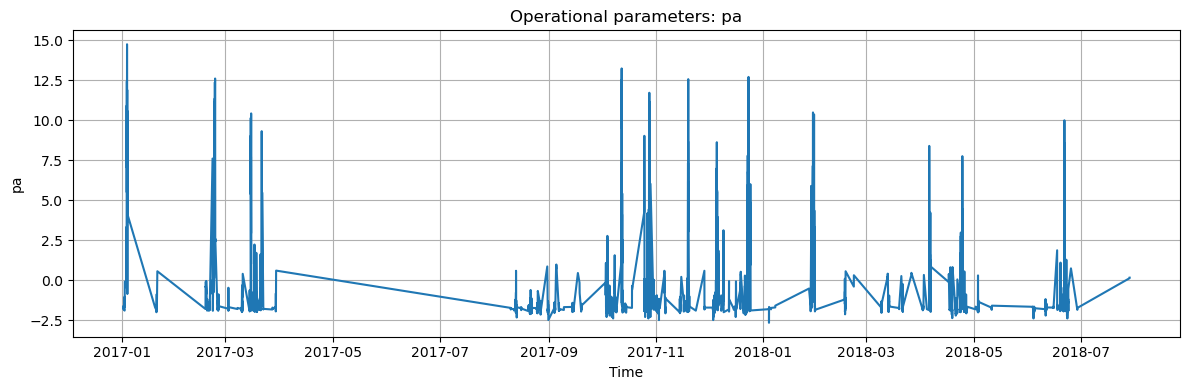

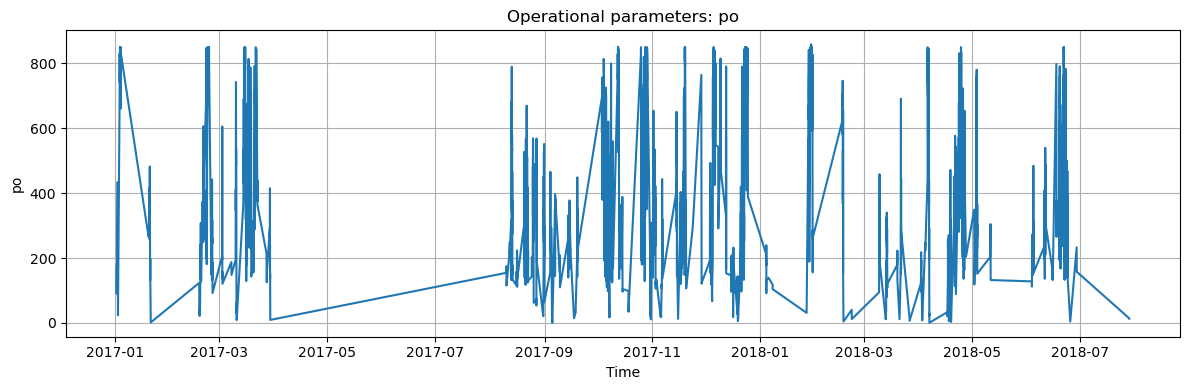

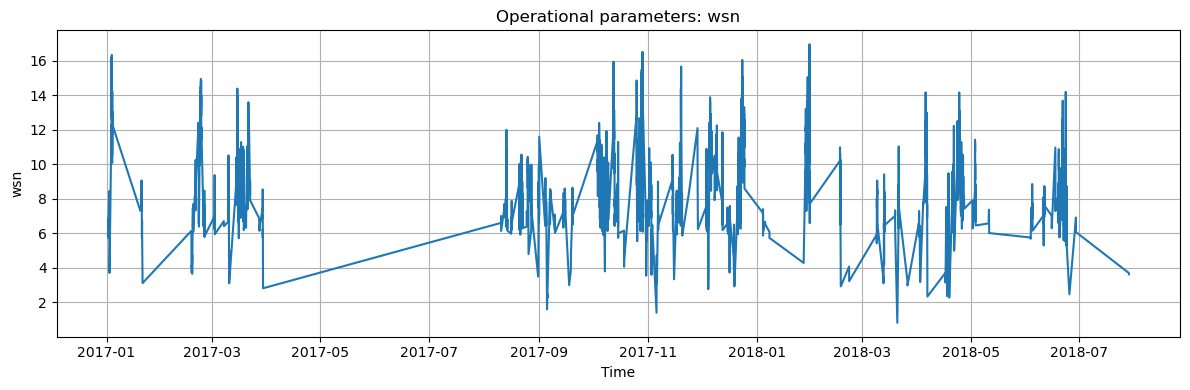

In [169]:
plot_columns(final_df, meteo_cols, "Wind direction at 41m")

plot_columns(final_df, operational_cols, "Operational parameters")

Load plotting function for checking for odd values.

In [183]:
def load_plot(df_plot: pd.DataFrame, cols: list[str], title: str, ylabel: str, colors: list[str]):

    plt.figure(figsize=(14, 8))
    labels = ["Mean", "Stdev", "Min", "Max", "DEL3", "DEL6", "DEL9", "DEL12"]
    for col, lab, color in zip(cols, labels, colors):
        if col in df_plot.columns:

            # mask out-of-range values
            series = df_plot[col].where(abs(df_plot[col]) <= 1e4, np.nan)
            plt.plot(df_plot["rname"], series, label=f"{lab} ({col})", linewidth=0.7, color = color)

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

From a first visualization, there are some values clearly out of range so an upper boundary is defined. 

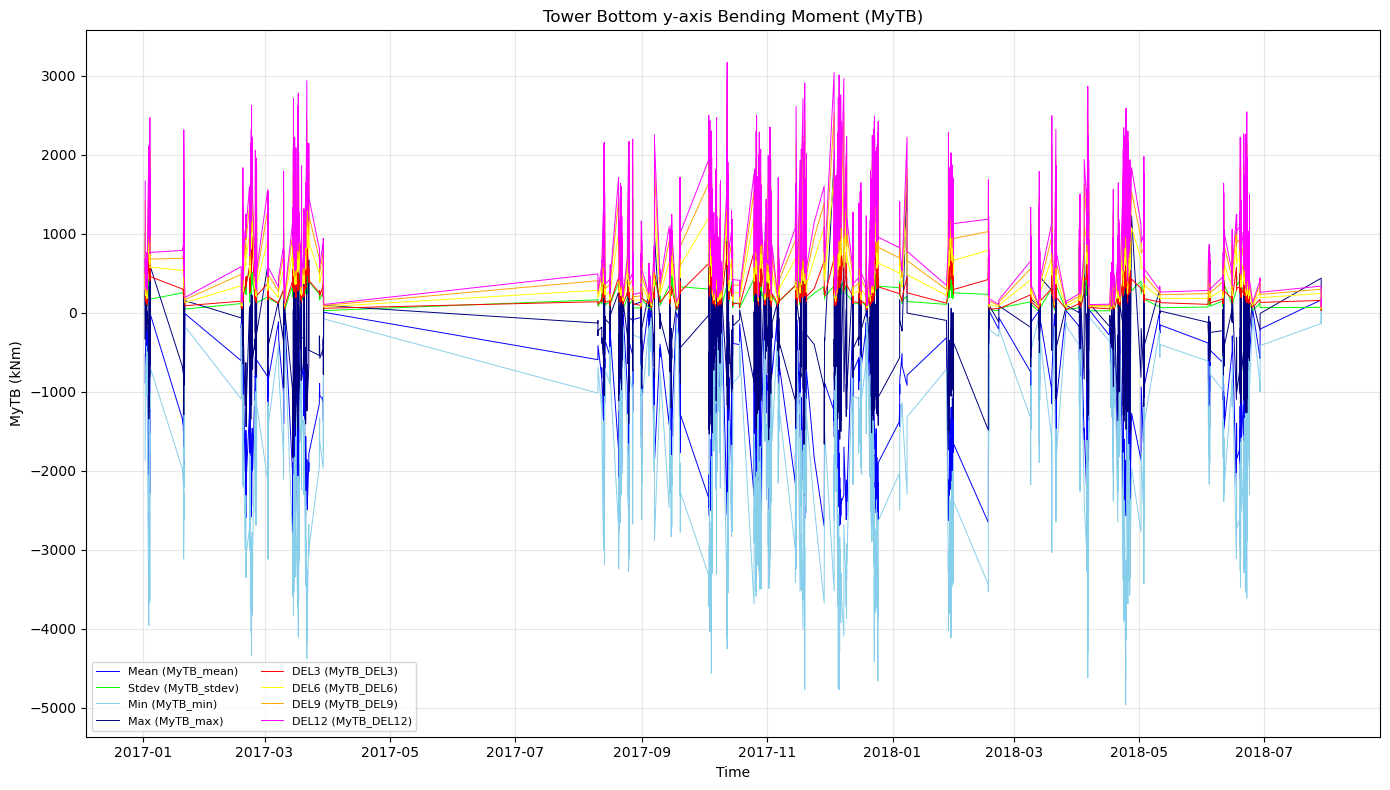

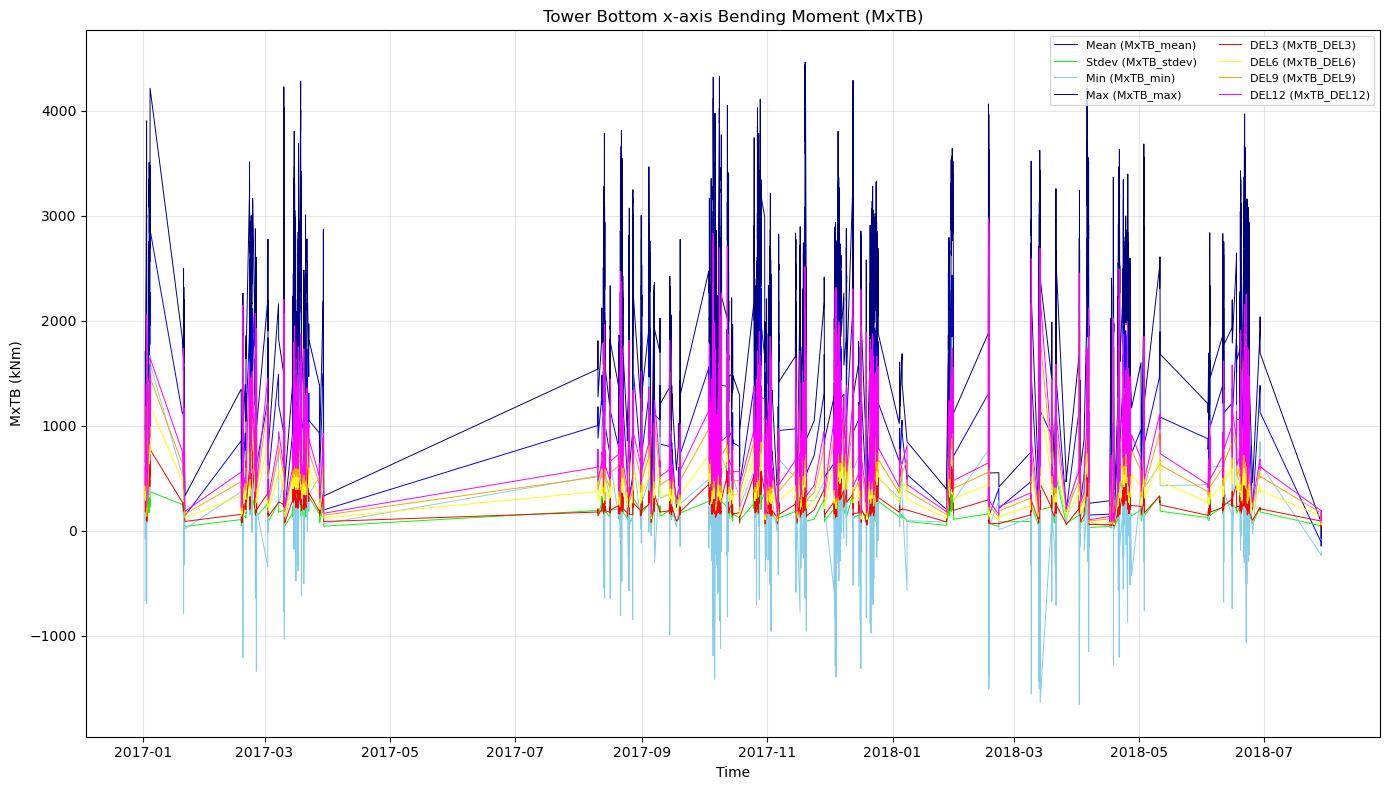

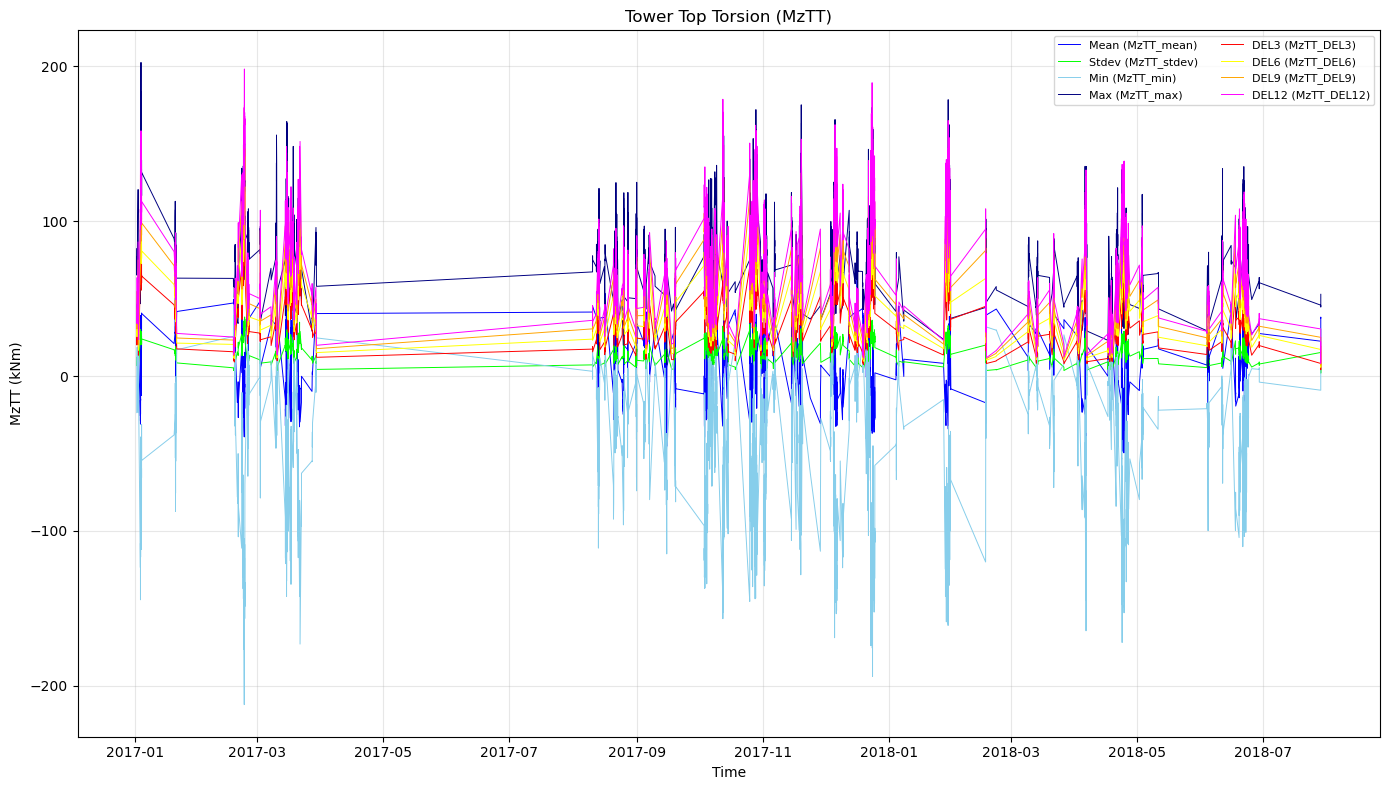

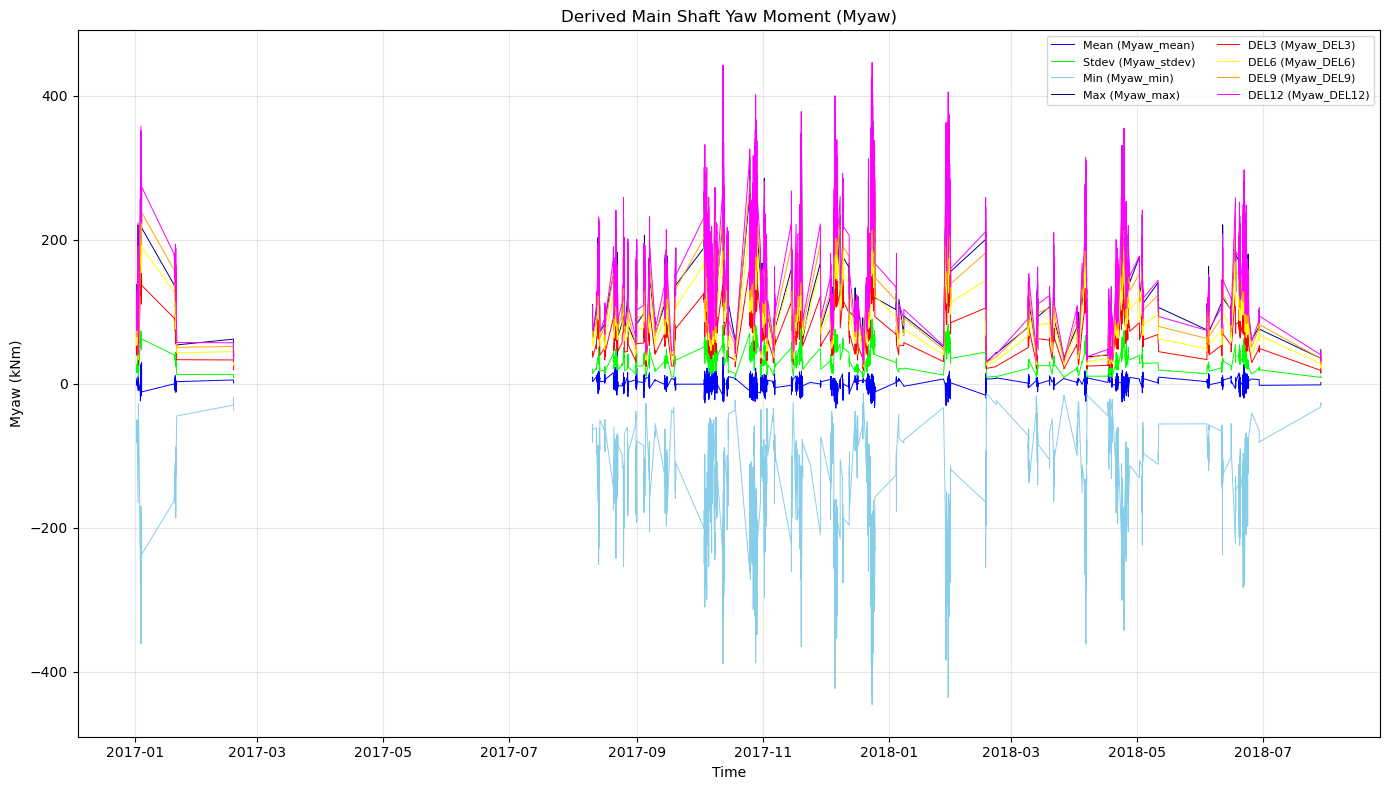

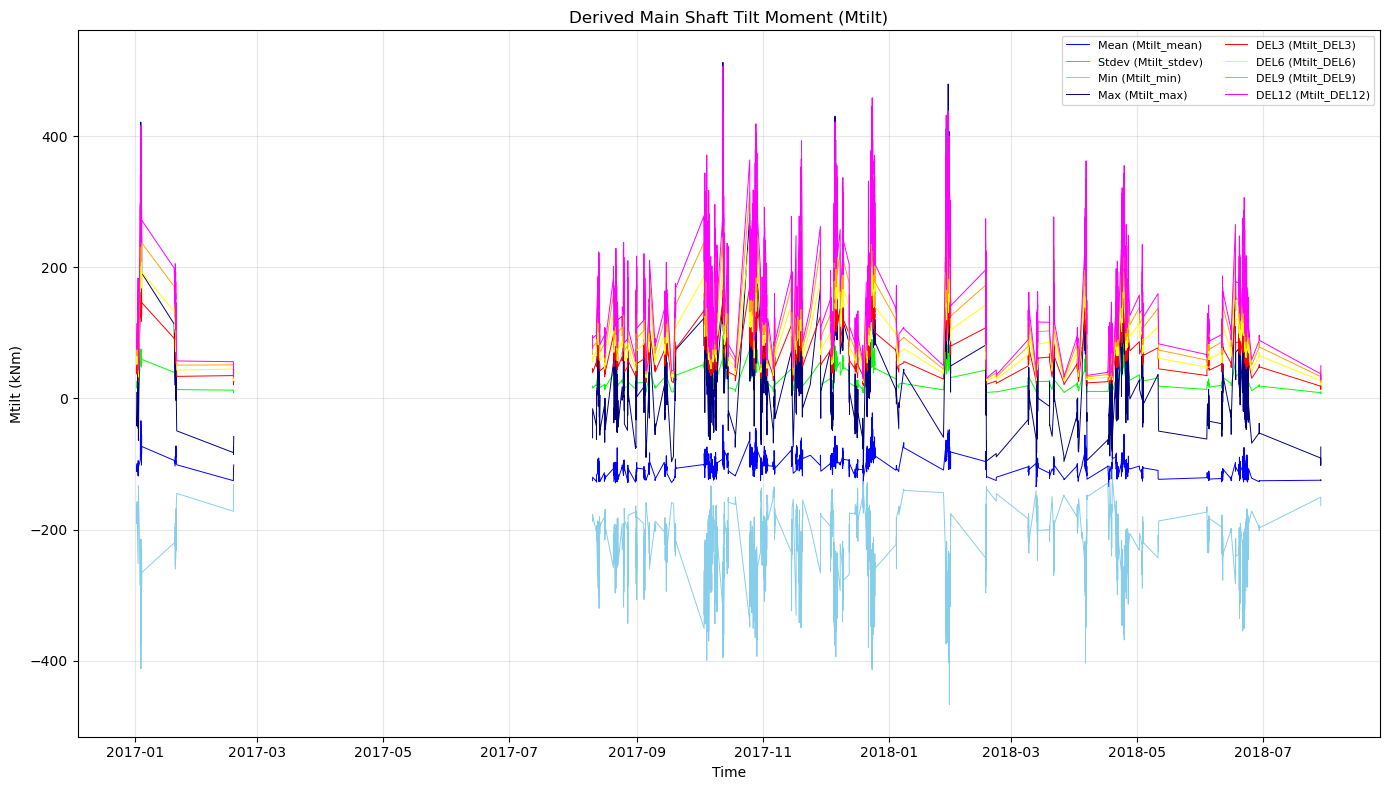

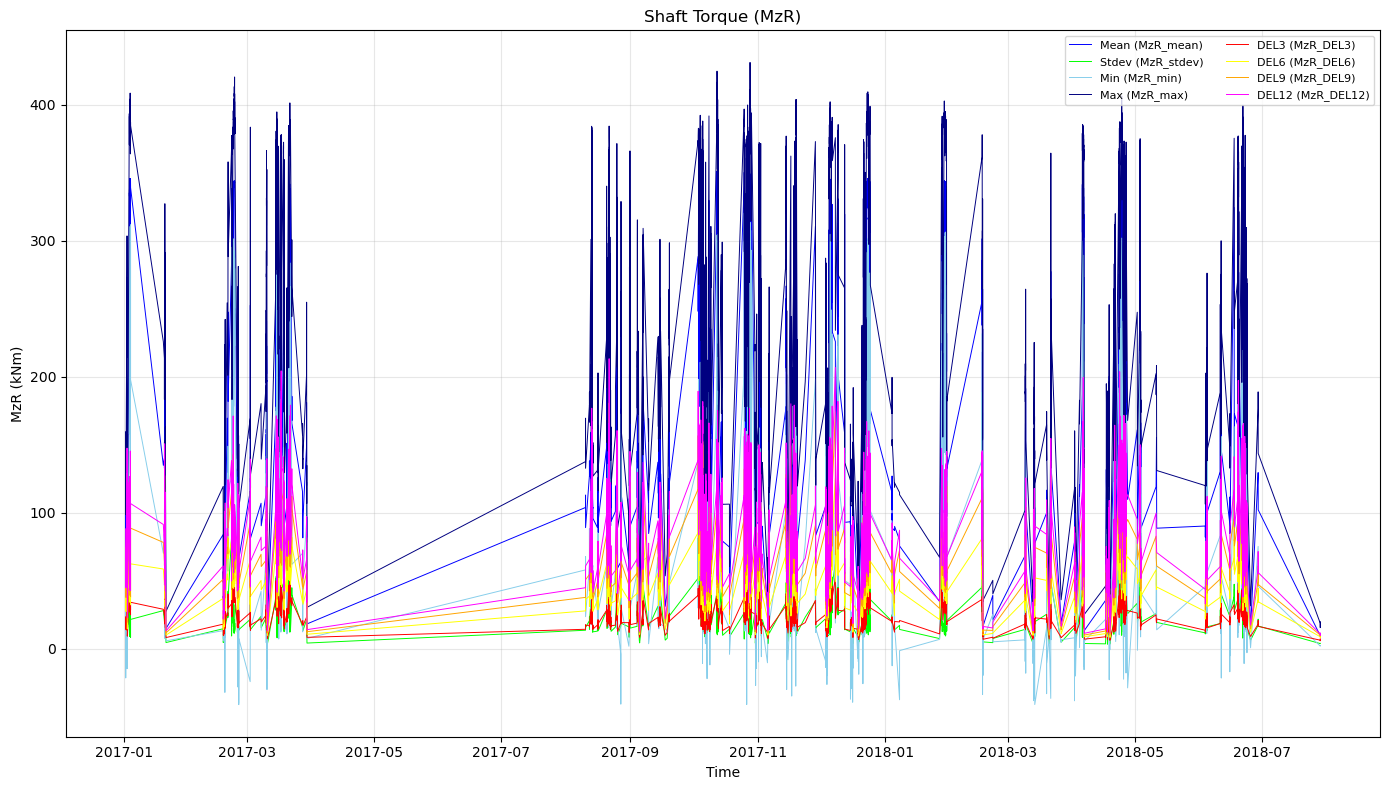

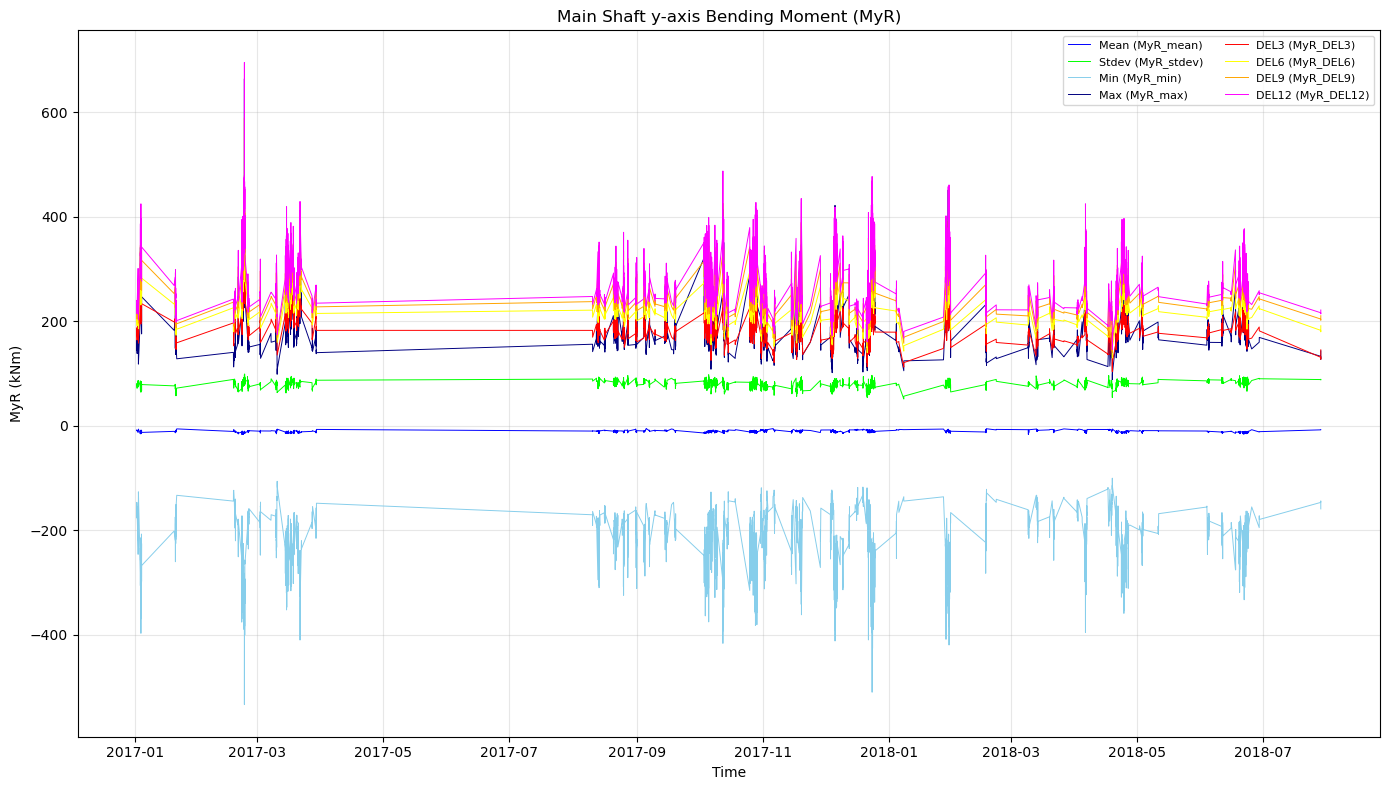

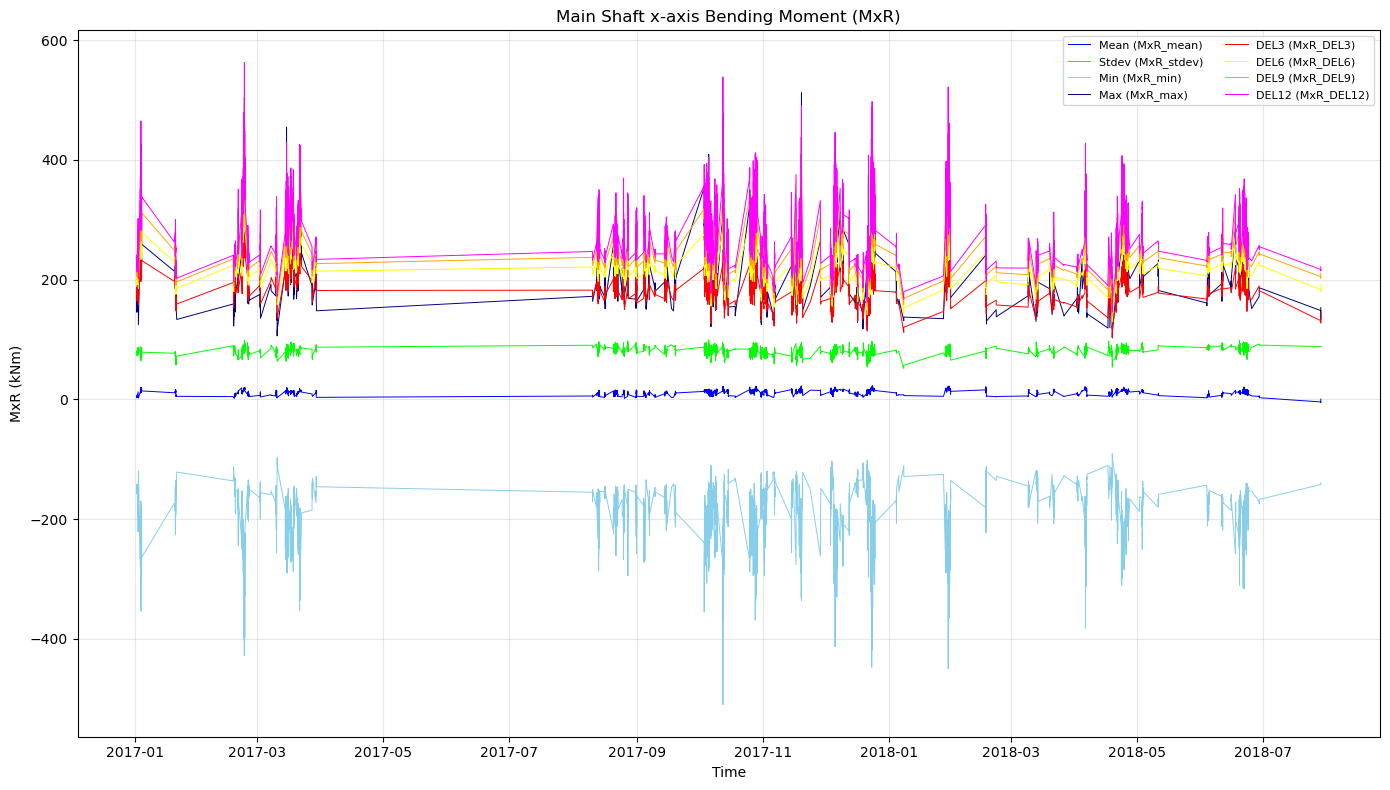

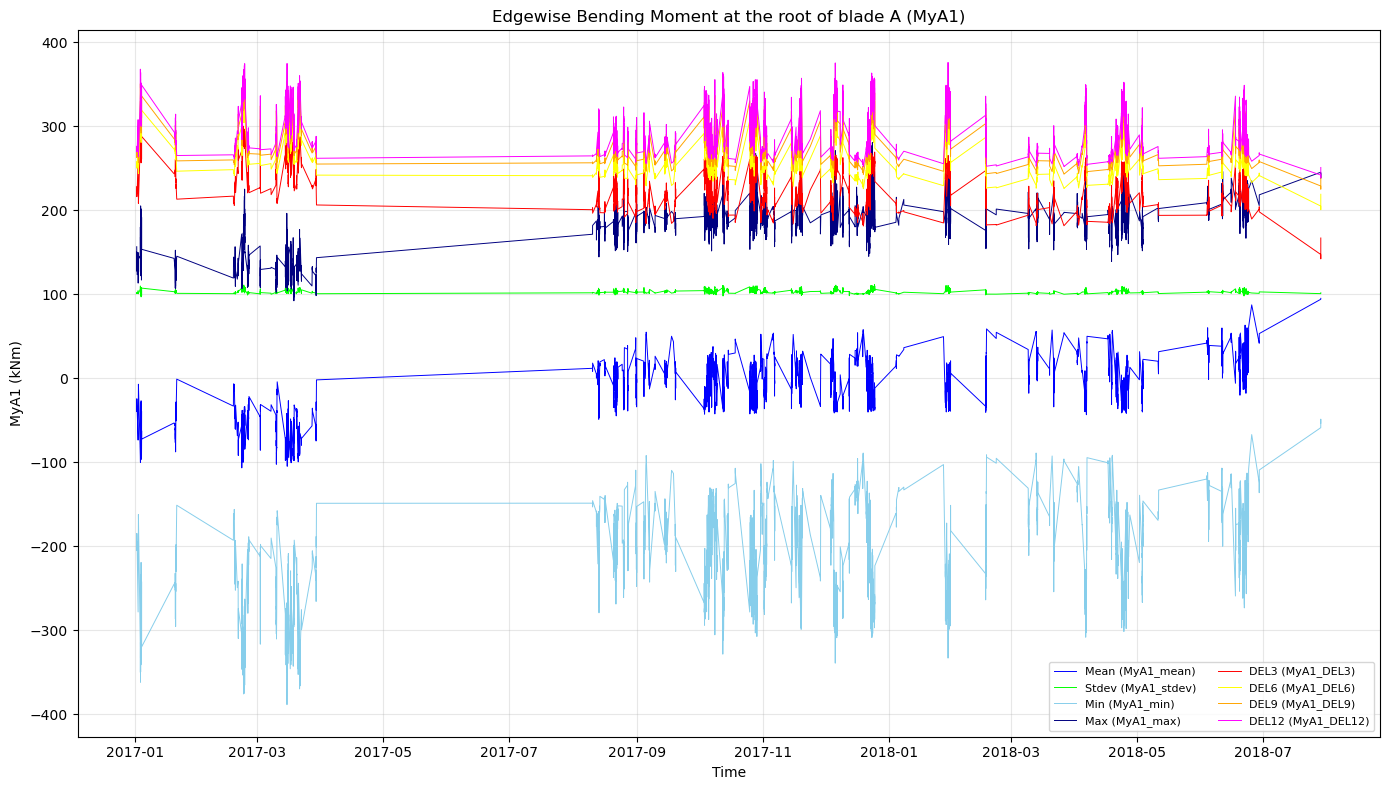

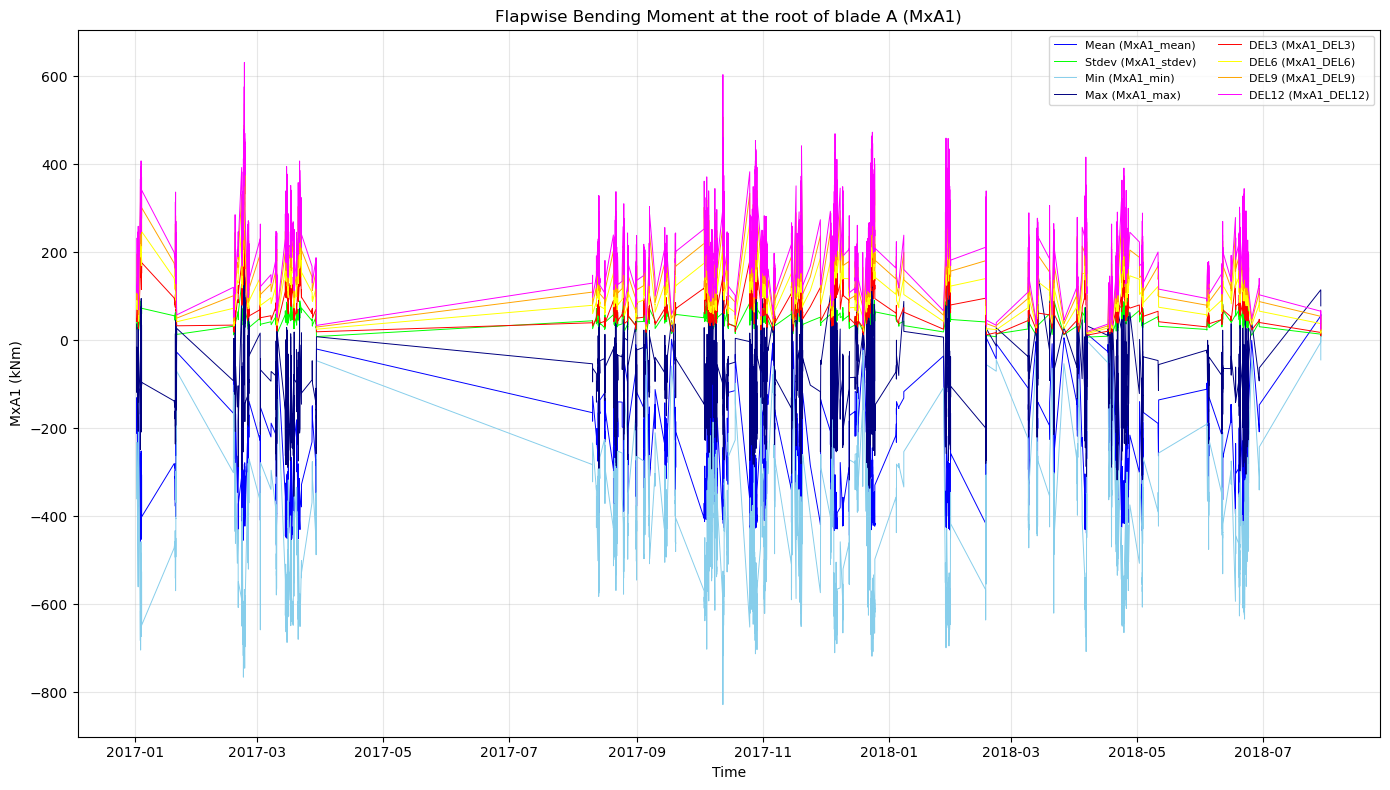

In [184]:
load_plot(
    final_df,
    ['MyTB_mean', 'MyTB_stdev', 'MyTB_min', 'MyTB_max', 'MyTB_DEL3', 'MyTB_DEL6', 'MyTB_DEL9', 'MyTB_DEL12'],
    "Tower Bottom y-axis Bending Moment (MyTB)",
    "MyTB (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MxTB_mean', 'MxTB_stdev', 'MxTB_min', 'MxTB_max', 'MxTB_DEL3', 'MxTB_DEL6', 'MxTB_DEL9', 'MxTB_DEL12'],
    "Tower Bottom x-axis Bending Moment (MxTB)",
    "MxTB (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MzTT_mean', 'MzTT_stdev', 'MzTT_min', 'MzTT_max', 'MzTT_DEL3', 'MzTT_DEL6', 'MzTT_DEL9', 'MzTT_DEL12'],
    "Tower Top Torsion (MzTT)",
    "MzTT (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['Myaw_mean', 'Myaw_stdev', 'Myaw_min', 'Myaw_max', 'Myaw_DEL3', 'Myaw_DEL6', 'Myaw_DEL9', 'Myaw_DEL12'],
    "Derived Main Shaft Yaw Moment (Myaw)",
    "Myaw (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['Mtilt_mean', 'Mtilt_stdev', 'Mtilt_min', 'Mtilt_max', 'Mtilt_DEL3', 'Mtilt_DEL6', 'Mtilt_DEL9', 'Mtilt_DEL12'],
    "Derived Main Shaft Tilt Moment (Mtilt)",
    "Mtilt (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MzR_mean', 'MzR_stdev', 'MzR_min', 'MzR_max', 'MzR_DEL3', 'MzR_DEL6', 'MzR_DEL9', 'MzR_DEL12'],
    'Shaft Torque (MzR)',
    'MzR (kNm)',
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MyR_mean', 'MyR_stdev', 'MyR_min', 'MyR_max', 'MyR_DEL3', 'MyR_DEL6', 'MyR_DEL9', 'MyR_DEL12'],
    "Main Shaft y-axis Bending Moment (MyR)",
    "MyR (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MxR_mean', 'MxR_stdev', 'MxR_min', 'MxR_max', 'MxR_DEL3', 'MxR_DEL6', 'MxR_DEL9', 'MxR_DEL12'],
    "Main Shaft x-axis Bending Moment (MxR)",
    "MxR (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MyA1_mean', 'MyA1_stdev', 'MyA1_min', 'MyA1_max', 'MyA1_DEL3', 'MyA1_DEL6', 'MyA1_DEL9', 'MyA1_DEL12'],
    'Edgewise Bending Moment at the root of blade A (MyA1)',
    'MyA1 (kNm)',
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MxA1_mean', 'MxA1_stdev', 'MxA1_min', 'MxA1_max', 'MxA1_DEL3', 'MxA1_DEL6', 'MxA1_DEL9', 'MxA1_DEL12'],
    'Flapwise Bending Moment at the root of blade A (MxA1)',
    'MxA1 (kNm)',
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

Wind speed bins definition

In [186]:
bins = np.arange(0, 20, 1)
labels = (bins[:-1] + bins[1:]) / 2  # midpoints of bins

final_df['bin'] = pd.cut(final_df, bins=bins, labels=labels)
final_df['bin']

ValueError: Input array must be 1 dimensional